In [3]:
import numpy as np
import pandas as pd

from scipy.stats import zscore

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score
)

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Reshape, Conv1D, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

In [4]:
df = pd.read_csv('../cardiovascular_diseases_processed.csv')
df.head()

,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE
0,50,2,168,62,110,80,1,1,0,0,1,0
1,55,1,156,85,140,90,3,1,0,0,1,1
2,52,1,165,64,130,70,3,1,0,0,0,1
3,48,2,169,82,150,100,1,1,0,0,1,1
4,48,1,156,56,100,60,1,1,0,0,0,0


Models


In [34]:
X = df.drop('CARDIO_DISEASE', axis=1)
y = df['CARDIO_DISEASE']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [36]:
scaler_new = StandardScaler()
X_train_scaled = scaler_new.fit_transform(X_train)
X_test_scaled = scaler_new.transform(X_test)

print("Train scaled shape:", X_train_scaled.shape)
print("Test scaled shape:", X_test_scaled.shape)

Train scaled shape: (54824, 11)
Test scaled shape: (13706, 11)


In [37]:
# 3) Evaluation helper

def evaluate_model(name, y_true, y_pred, y_prob=None):
    print(f"\n===== {name} =====")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 4))
    print("Precision:", round(precision_score(y_true, y_pred), 4))
    print("Recall   :", round(recall_score(y_true, y_pred), 4))
    print("F1-score :", round(f1_score(y_true, y_pred), 4))
    
    if y_prob is not None:
        print("ROC-AUC  :", round(roc_auc_score(y_true, y_prob), 4))
    
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, digits=4))

In [38]:
# 4) Random Forest baseline

rf_comp = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_comp.fit(X_train, y_train)
rf_pred = rf_comp.predict(X_test)
rf_prob = rf_comp.predict_proba(X_test)[:, 1]

evaluate_model("Random Forest", y_test, rf_pred, rf_prob)


===== Random Forest =====
Accuracy : 0.7258
Precision: 0.7363
Recall   : 0.6953
F1-score : 0.7152
ROC-AUC  : 0.787

Confusion Matrix:
[[5230 1690]
 [2068 4718]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7166    0.7558    0.7357      6920
           1     0.7363    0.6953    0.7152      6786

    accuracy                         0.7258     13706
   macro avg     0.7265    0.7255    0.7254     13706
weighted avg     0.7264    0.7258    0.7255     13706



In [39]:
# 5) AdaBoost baseline

adb = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

adb.fit(X_train, y_train)
adb_pred = adb.predict(X_test)
adb_prob = adb.predict_proba(X_test)[:, 1]

evaluate_model("AdaBoost", y_test, adb_pred, adb_prob)


===== AdaBoost =====
Accuracy : 0.7153
Precision: 0.765
Recall   : 0.6135
F1-score : 0.6809
ROC-AUC  : 0.7873

Confusion Matrix:
[[5641 1279]
 [2623 4163]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6826    0.8152    0.7430      6920
           1     0.7650    0.6135    0.6809      6786

    accuracy                         0.7153     13706
   macro avg     0.7238    0.7143    0.7120     13706
weighted avg     0.7234    0.7153    0.7123     13706



In [ ]:
# 6) SVM baseline

svm = SVC(
    C=1.0,
    kernel="rbf",
    gamma="scale",
    probability=True,
    random_state=42
)

svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)
svm_prob = svm.predict_proba(X_test_scaled)[:, 1]

evaluate_model("SVM", y_test, svm_pred, svm_prob)


===== SVM =====
Accuracy : 0.7327
Precision: 0.7628
Recall   : 0.6677
F1-score : 0.7121
ROC-AUC  : 0.7913

Confusion Matrix:
[[5511 1409]
 [2255 4531]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7096    0.7964    0.7505      6920
           1     0.7628    0.6677    0.7121      6786

    accuracy                         0.7327     13706
   macro avg     0.7362    0.7320    0.7313     13706
weighted avg     0.7360    0.7327    0.7315     13706



In [ ]:
# 7)  MLP baseline

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=50,
    early_stopping=True,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
mlp_pred = mlp.predict(X_test_scaled)
mlp_prob = mlp.predict_proba(X_test_scaled)[:, 1]

evaluate_model("ANN / MLP", y_test, mlp_pred, mlp_prob)


===== ANN / MLP =====
Accuracy : 0.7333
Precision: 0.7455
Recall   : 0.7004
F1-score : 0.7222
ROC-AUC  : 0.8002

Confusion Matrix:
[[5297 1623]
 [2033 4753]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7226    0.7655    0.7434      6920
           1     0.7455    0.7004    0.7222      6786

    accuracy                         0.7333     13706
   macro avg     0.7340    0.7329    0.7328     13706
weighted avg     0.7339    0.7333    0.7329     13706



In [ ]:
# 8) 1D CNN 

n_features = X_train_scaled.shape[1]

y_train_cat = to_categorical(y_train, num_classes=2)
y_test_cat = to_categorical(y_test, num_classes=2)


cnn_model = Sequential([
    Dense(128, activation="relu", input_shape=(n_features,)),
    Dropout(0.3),
    
  
    Reshape((32, 4)),
    
    Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
    Dropout(0.2),
    
    Conv1D(filters=32, kernel_size=3, activation="relu", padding="same"),
    Flatten(),
    
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(2, activation="softmax")
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_comp = cnn_model.fit(
    X_train_scaled,
    y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

cnn_prob = cnn_model.predict(X_test_scaled)[:, 1]
cnn_pred = (cnn_prob >= 0.5).astype(int)

evaluate_model("1D CNN", y_test, cnn_pred, cnn_prob)

C:\Users\Sigma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7186 - loss: 0.5701 - val_accuracy: 0.7265 - val_loss: 0.5542
Epoch 2/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7260 - loss: 0.5551 - val_accuracy: 0.7318 - val_loss: 0.5506
Epoch 3/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7298 - loss: 0.5528 - val_accuracy: 0.7303 - val_loss: 0.5466
Epoch 4/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7329 - loss: 0.5499 - val_accuracy: 0.7290 - val_loss: 0.5489
Epoch 5/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7322 - loss: 0.5485 - val_accuracy: 0.7300 - val_loss: 0.5471
Epoch 6/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7308 - loss: 0.5485 - val_accuracy: 0.7302 - val_loss: 0.5469
Epoch 7/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7319 - loss: 0.5476 - val_accuracy: 0.7307 - val_loss: 0.5463
Epoch 8/30
172/172 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7339 - loss: 0.5467 - val_accuracy: 0.

Models with the new features 

In [6]:
df_cleaned = pd.read_csv('D:\study\semster 2 year 3\XAI\XAI github\cardiovascular_fe.csv')
df_cleaned.head()

,AGE,GENDER,HEIGHT,WEIGHT,AP_HIGH,AP_LOW,CHOLESTEROL,GLUCOSE,SMOKE,ALCOHOL,PHYSICAL_ACTIVITY,CARDIO_DISEASE,BMI,PULSE_PRESSURE,MAP,RISK_SCORE,METABOLIC_RISK,AGE_BP_RISK
0,50,2,168,62,110,80,1,1,0,0,1,0,21.967120,30,90.000000,50,2,5500
1,55,1,156,85,140,90,3,1,0,0,1,1,34.927679,50,106.666667,165,4,7700
2,52,1,165,64,130,70,3,1,0,0,0,1,23.507805,60,90.000000,156,4,6760
3,48,2,169,82,150,100,1,1,0,0,1,1,28.710479,50,116.666667,48,2,7200
4,60,1,151,67,120,80,2,2,0,0,0,0,29.384676,40,93.333333,120,4,7200


In [40]:
M = df_cleaned.drop('CARDIO_DISEASE', axis=1)
N = df_cleaned['CARDIO_DISEASE']

In [41]:
from sklearn.model_selection import train_test_split

M_train, M_test, N_train, N_test = train_test_split(
    M, N,
    test_size=0.2,
    random_state=42,
    stratify=N
)

In [42]:

scaler_new = StandardScaler()
M_train_scaled = scaler_new.fit_transform(M_train)
M_test_scaled = scaler_new.transform(M_test)

print("Train scaled shape:", M_train_scaled.shape)
print("Test scaled shape:", M_test_scaled.shape)

Train scaled shape: (50010, 17)
Test scaled shape: (12503, 17)


In [43]:
# 4) Random Forest baseline

rf_comp = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_comp.fit(M_train, N_train)
rf_pred = rf_comp.predict(M_test)
rf_prob = rf_comp.predict_proba(M_test)[:, 1]

evaluate_model("Random Forest", N_test, rf_pred, rf_prob)


===== Random Forest =====
Accuracy : 0.7118
Precision: 0.722
Recall   : 0.6772
F1-score : 0.6989
ROC-AUC  : 0.7718

Confusion Matrix:
[[4718 1610]
 [1993 4182]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7030    0.7456    0.7237      6328
           1     0.7220    0.6772    0.6989      6175

    accuracy                         0.7118     12503
   macro avg     0.7125    0.7114    0.7113     12503
weighted avg     0.7124    0.7118    0.7115     12503



In [44]:
# 5) AdaBoost baseline

adb = AdaBoostClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42
)

adb.fit(M_train, N_train)
adb_pred = adb.predict(M_test)
adb_prob = adb.predict_proba(M_test)[:, 1]

evaluate_model("AdaBoost", N_test, adb_pred, adb_prob)


===== AdaBoost =====
Accuracy : 0.7173
Precision: 0.7635
Recall   : 0.6194
F1-score : 0.684
ROC-AUC  : 0.7843

Confusion Matrix:
[[5143 1185]
 [2350 3825]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6864    0.8127    0.7442      6328
           1     0.7635    0.6194    0.6840      6175

    accuracy                         0.7173     12503
   macro avg     0.7249    0.7161    0.7141     12503
weighted avg     0.7245    0.7173    0.7145     12503



In [77]:
# 6) SVM baseline

svm = SVC(
    C=1.0,
    kernel="rbf",
    gamma="scale",
    probability=True,
    random_state=42
)

svm.fit(M_train_scaled, N_train)
svm_pred = svm.predict(M_test_scaled)
svm_prob = svm.predict_proba(M_test_scaled)[:, 1]

evaluate_model("SVM", N_test, svm_pred, svm_prob)


===== SVM =====
Accuracy : 0.7268
Precision: 0.7655
Recall   : 0.644
F1-score : 0.6996
ROC-AUC  : 0.7788

Confusion Matrix:
[[5110 1218]
 [2198 3977]]

Classification Report:
              precision    recall  f1-score   support

           0     0.6992    0.8075    0.7495      6328
           1     0.7655    0.6440    0.6996      6175

    accuracy                         0.7268     12503
   macro avg     0.7324    0.7258    0.7245     12503
weighted avg     0.7320    0.7268    0.7248     12503



In [74]:
# 7) MLP baseline

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=50,
    early_stopping=True,
    random_state=42
)

mlp.fit(M_train_scaled, N_train)
mlp_pred = mlp.predict(M_test_scaled)
mlp_prob = mlp.predict_proba(M_test_scaled)[:, 1]

evaluate_model("ANN / MLP", N_test, mlp_pred, mlp_prob)


===== ANN / MLP =====
Accuracy : 0.7245
Precision: 0.7384
Recall   : 0.6849
F1-score : 0.7106
ROC-AUC  : 0.7895

Confusion Matrix:
[[4830 1498]
 [1946 4229]]

Classification Report:
              precision    recall  f1-score   support

           0     0.7128    0.7633    0.7372      6328
           1     0.7384    0.6849    0.7106      6175

    accuracy                         0.7245     12503
   macro avg     0.7256    0.7241    0.7239     12503
weighted avg     0.7255    0.7245    0.7241     12503



In [78]:
# 1D CNN
n_features = M_train_scaled.shape[1]

N_train_cat = to_categorical(N_train, num_classes=2)
N_test_cat = to_categorical(N_test, num_classes=2)


cnn_model = Sequential([
    Dense(128, activation="relu", input_shape=(n_features,)),
    Dropout(0.3),
    
    Reshape((32, 4)),  
    
    Conv1D(filters=64, kernel_size=3, activation="relu", padding="same"),
    Dropout(0.2),
    
    Conv1D(filters=32, kernel_size=3, activation="relu", padding="same"),
    Flatten(),
    
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(2, activation="softmax")
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_comp = cnn_model.fit(
    M_train_scaled,
    N_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

cnn_prob = cnn_model.predict(M_test_scaled)[:, 1]
cnn_pred = (cnn_prob >= 0.5).astype(int)

evaluate_model("1D CNN", N_test, cnn_pred, cnn_prob)

C:\Users\Sigma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7148 - loss: 0.5696 - val_accuracy: 0.7242 - val_loss: 0.5550
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7278 - loss: 0.5562 - val_accuracy: 0.7276 - val_loss: 0.5546
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7274 - loss: 0.5542 - val_accuracy: 0.7274 - val_loss: 0.5543
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7273 - loss: 0.5544 - val_accuracy: 0.7266 - val_loss: 0.5551
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7280 - loss: 0.5536 - val_accuracy: 0.7303 - val_loss: 0.5549
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7307 - loss: 0.5500 - val_accuracy: 0.7301 - val_loss: 0.5519
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7301 - loss: 0.5502 - val_accuracy: 0.7311 - val_loss: 0.5541
Epoch 8/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7303 - loss: 0.5499 - val_accuracy: 0.

Interpretablity techniques

In [45]:
rf_selector = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)

rfe_rf = RFE(estimator=rf_selector, n_features_to_select=8)
rfe_rf.fit(M_train, N_train)

selected_features_rf = M.columns[rfe_rf.support_]
print("Selected Features by RF-RFE:")
print(selected_features_rf)

Selected Features by RF-RFE:
Index(['AGE', 'HEIGHT', 'WEIGHT', 'AP_HIGH', 'BMI', 'MAP', 'RISK_SCORE',
       'AGE_BP_RISK'],
      dtype='str')


In [46]:
X_vif = df_cleaned.drop(columns=['CARDIO_DISEASE']).copy()
X_vif = X_vif.select_dtypes(include=['number'])
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]

print(vif_data.sort_values(by='VIF', ascending=False))

C:\Users\Sigma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


              Feature           VIF
8             GLUCOSE           inf
5             AP_HIGH           inf
14                MAP           inf
16     METABOLIC_RISK           inf
7         CHOLESTEROL           inf
6              AP_LOW           inf
13     PULSE_PRESSURE           inf
0               const  2.394728e+04
17        AGE_BP_RISK  1.817466e+02
4              WEIGHT  1.292403e+02
12                BMI  1.246347e+02
15         RISK_SCORE  9.472865e+01
1                 AGE  8.015534e+01
3              HEIGHT  3.964277e+01
2              GENDER  1.499138e+00
9               SMOKE  1.248450e+00
10            ALCOHOL  1.140154e+00
11  PHYSICAL_ACTIVITY  1.001956e+00


In [ ]:
lr = LogisticRegression(max_iter=2000, random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=8)
rfe.fit(M_train_scaled, N_train)

rfe_results = pd.DataFrame({
    'Feature': M.columns,
    'Selected': rfe.support_,
    'Rank': rfe.ranking_
}).sort_values(by=['Selected', 'Rank'], ascending=[False, True])

print(rfe_results)

              Feature  Selected  Rank
0                 AGE      True     1
4             AP_HIGH      True     1
5              AP_LOW      True     1
6         CHOLESTEROL      True     1
12     PULSE_PRESSURE      True     1
13                MAP      True     1
14         RISK_SCORE      True     1
16        AGE_BP_RISK      True     1
15     METABOLIC_RISK     False     2
7             GLUCOSE     False     3
3              WEIGHT     False     4
10  PHYSICAL_ACTIVITY     False     5
8               SMOKE     False     6
2              HEIGHT     False     7
11                BMI     False     8
9             ALCOHOL     False     9
1              GENDER     False    10


In [49]:
mlp_rfe = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=100,
    early_stopping=True,
    random_state=42
)

mlp_rfe.fit(M_train_scaled, N_train)

N_pred_rfe = mlp_rfe.predict(M_test_scaled)
N_prob_rfe = mlp_rfe.predict_proba(M_test_scaled)[:, 1]

print("MLP with RFE")
print("Accuracy :", accuracy_score(N_test, N_pred_rfe))
print("Precision:", precision_score(N_test, N_pred_rfe))
print("Recall   :", recall_score(N_test, N_pred_rfe))
print("F1       :", f1_score(N_test, N_pred_rfe))
print("ROC-AUC  :", roc_auc_score(N_test, N_prob_rfe))

MLP with RFE
Accuracy : 0.7245461089338558
Precision: 0.7384319888248647
Recall   : 0.6848582995951417
F1       : 0.7106368677533188
ROC-AUC  : 0.7895063646181486


In [69]:
mlp_orig = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    alpha=1e-4,
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=100,
    early_stopping=True,
    random_state=42
)

mlp_orig.fit(M_train_scaled, N_train)

mlp_pred = mlp_orig.predict(M_test_scaled)
mlp_prob = mlp_orig.predict_proba(M_test_scaled)[:, 1]


comparison_rfe = pd.DataFrame([
    ['MLP Original Features',accuracy_score(N_test, mlp_pred),
     precision_score(N_test, mlp_pred),
     recall_score(N_test, mlp_pred),
     f1_score(N_test, mlp_pred),
     roc_auc_score(N_test, mlp_prob)],
    ['MLP After RFE', 
     accuracy_score(N_test, N_pred_rfe),
     precision_score(N_test, N_pred_rfe),
     recall_score(N_test, N_pred_rfe),
     f1_score(N_test, N_pred_rfe),
     roc_auc_score(N_test, N_prob_rfe)]
], columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC'])

print(comparison_rfe)

                   Model  Accuracy  Precision    Recall        F1   ROC_AUC
0  MLP Original Features  0.724546   0.738432  0.684858  0.710637  0.789506
1          MLP After RFE  0.724546   0.738432  0.684858  0.710637  0.789506


              Feature  Importance
4             AP_HIGH    0.034195
14         RISK_SCORE    0.006196
16        AGE_BP_RISK    0.005242
13                MAP    0.003447
10  PHYSICAL_ACTIVITY    0.002071
0                 AGE    0.001776
6         CHOLESTEROL    0.001514
5              AP_LOW    0.001133
8               SMOKE    0.000558
9             ALCOHOL    0.000057
12     PULSE_PRESSURE    0.000042
11                BMI   -0.000678
1              GENDER   -0.000731
7             GLUCOSE   -0.000862
15     METABOLIC_RISK   -0.001619
2              HEIGHT   -0.002336
3              WEIGHT   -0.004237


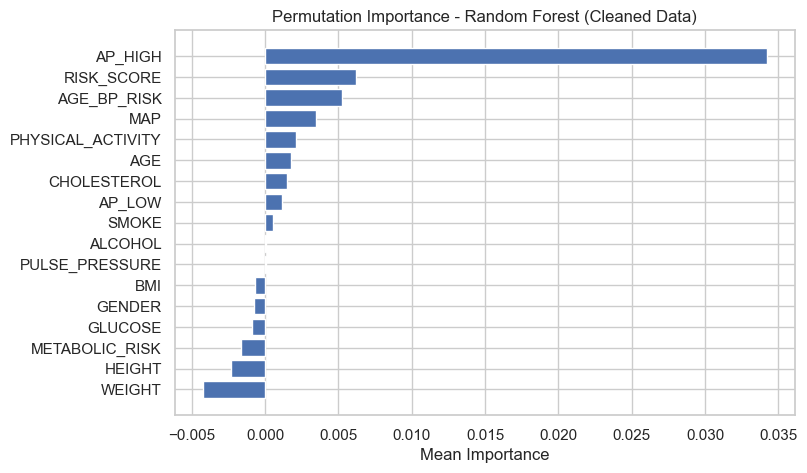

In [70]:

from sklearn.inspection import permutation_importance


perm_rf = permutation_importance(
    rf_comp,          
    M_test,
    N_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)

perm_rf_df = pd.DataFrame({
    'Feature': M.columns,
    'Importance': perm_rf.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_rf_df)

plt.figure(figsize=(8, 5))
plt.barh(perm_rf_df['Feature'], perm_rf_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Permutation Importance - Random Forest (Cleaned Data)')
plt.xlabel('Mean Importance')
plt.show()

              Feature  Importance
11                BMI    0.154585
4             AP_HIGH    0.114360
3              WEIGHT    0.114285
2              HEIGHT    0.108927
16        AGE_BP_RISK    0.106466
13                MAP    0.095498
14         RISK_SCORE    0.072576
0                 AGE    0.050287
12     PULSE_PRESSURE    0.049644
5              AP_LOW    0.038601
6         CHOLESTEROL    0.019429
15     METABOLIC_RISK    0.019384
1              GENDER    0.017224
10  PHYSICAL_ACTIVITY    0.014922
7             GLUCOSE    0.009905
8               SMOKE    0.008204
9             ALCOHOL    0.005702


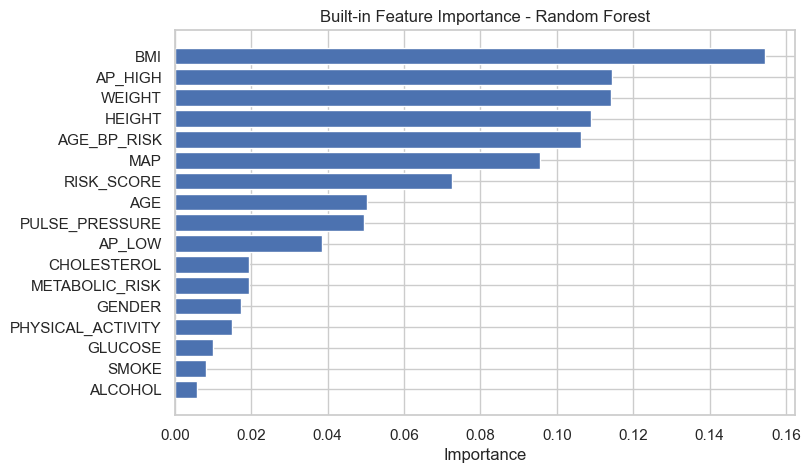

In [71]:
rf_importance_df = pd.DataFrame({
    'Feature': M.columns,
    'Importance': rf_comp.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(rf_importance_df)

plt.figure(figsize=(8, 5))
plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Built-in Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.show()

              Feature  Importance
6         CHOLESTEROL    0.019051
16        AGE_BP_RISK    0.014368
0                 AGE    0.012832
12     PULSE_PRESSURE    0.012226
13                MAP    0.010868
4             AP_HIGH    0.009456
10  PHYSICAL_ACTIVITY    0.003968
15     METABOLIC_RISK    0.003896
5              AP_LOW    0.003768
11                BMI    0.002969
14         RISK_SCORE    0.001941
9             ALCOHOL    0.000852
2              HEIGHT    0.000446
8               SMOKE    0.000040
3              WEIGHT   -0.000073
1              GENDER   -0.000191
7             GLUCOSE   -0.002090


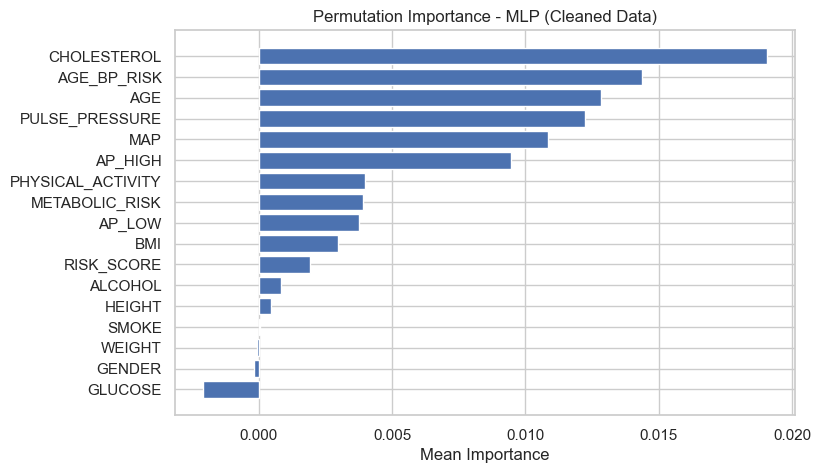

In [75]:
perm_mlp = permutation_importance(
    mlp,      
    M_test_scaled,
    N_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)

perm_mlp_df = pd.DataFrame({
    'Feature': M.columns,
    'Importance': perm_mlp.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_mlp_df)

plt.figure(figsize=(8, 5))
plt.barh(perm_mlp_df['Feature'], perm_mlp_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Permutation Importance - MLP (Cleaned Data)')
plt.xlabel('Mean Importance')
plt.show()

              Feature  Importance
12     PULSE_PRESSURE    0.010821
16        AGE_BP_RISK    0.009961
6         CHOLESTEROL    0.009695
4             AP_HIGH    0.009524
14         RISK_SCORE    0.007942
13                MAP    0.006787
0                 AGE    0.005674
5              AP_LOW    0.004873
10  PHYSICAL_ACTIVITY    0.003424
11                BMI    0.000697
9             ALCOHOL    0.000666
8               SMOKE    0.000619
1              GENDER    0.000429
2              HEIGHT    0.000402
3              WEIGHT   -0.000011
15     METABOLIC_RISK   -0.000471
7             GLUCOSE   -0.001520


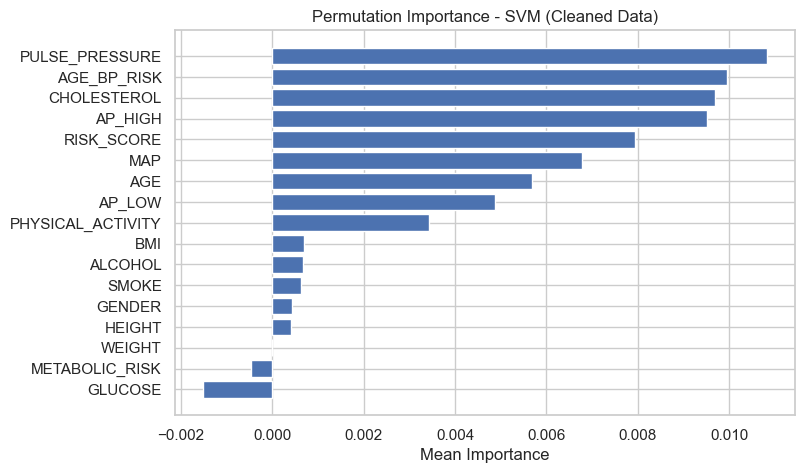

In [79]:
perm_svm = permutation_importance(
    svm,         
    M_test_scaled,
    N_test,
    n_repeats=10,
    random_state=42,
    scoring='f1'
)

perm_svm_df = pd.DataFrame({
    'Feature': M.columns,
    'Importance': perm_svm.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_svm_df)

plt.figure(figsize=(8, 5))
plt.barh(perm_svm_df['Feature'], perm_svm_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Permutation Importance - SVM (Cleaned Data)')
plt.xlabel('Mean Importance')
plt.show()

In [80]:
import numpy as np
from sklearn.base import BaseEstimator, ClassifierMixin

class KerasBinaryWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model):
        self.model = model

    def fit(self, X, y):
        return self

    def predict(self, X):
        probs = self.model.predict(X, verbose=0)[:, 1]
        return (probs >= 0.5).astype(int)

    def predict_proba(self, X):
        probs = self.model.predict(X, verbose=0)[:, 1]
        return np.column_stack([1 - probs, probs])

cnn_wrapper = KerasBinaryWrapper(cnn_model)  

              Feature  Importance
0                 AGE    0.012574
4             AP_HIGH    0.011509
16        AGE_BP_RISK    0.011043
13                MAP    0.009141
14         RISK_SCORE    0.008930
12     PULSE_PRESSURE    0.006007
6         CHOLESTEROL    0.005190
5              AP_LOW    0.004731
10  PHYSICAL_ACTIVITY    0.003268
15     METABOLIC_RISK    0.001133
9             ALCOHOL    0.000791
8               SMOKE    0.000714
11                BMI    0.000188
1              GENDER   -0.001259
3              WEIGHT   -0.001537
2              HEIGHT   -0.001957
7             GLUCOSE   -0.001958


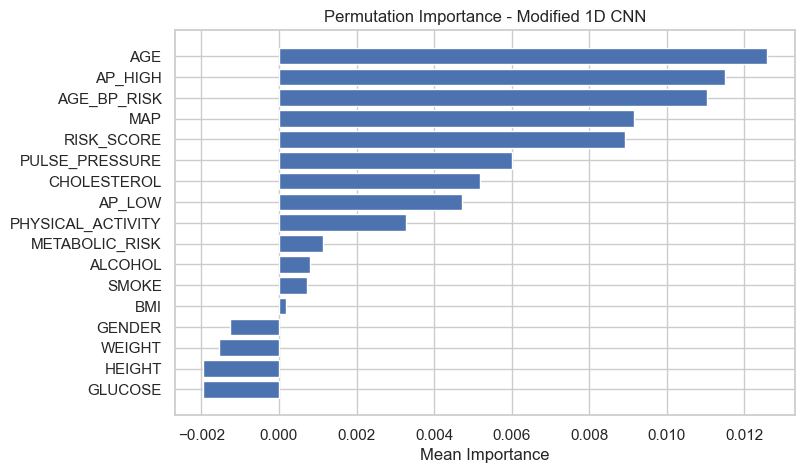

In [81]:
perm_cnn = permutation_importance(
    cnn_wrapper,
    M_test_scaled,
    N_test,
    n_repeats=5,
    random_state=42,
    scoring='f1'
)

perm_cnn_df = pd.DataFrame({
    'Feature': M.columns,
    'Importance': perm_cnn.importances_mean
}).sort_values(by='Importance', ascending=False)

print(perm_cnn_df)

plt.figure(figsize=(8, 5))
plt.barh(perm_cnn_df['Feature'], perm_cnn_df['Importance'])
plt.gca().invert_yaxis()
plt.title('Permutation Importance - Modified 1D CNN')
plt.xlabel('Mean Importance')
plt.show()

In [ ]:
# !pip install shap -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\Sigma\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [55]:
print(M_train.shape)
print(M_test.shape)

print(list(M_train.columns) == list(M_test.columns))

(50010, 17)
(12503, 17)
True


In [53]:
import shap

explainer_rf = shap.Explainer(rf_comp, M_train)


C:\Users\Sigma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [56]:
shap_values_rf = explainer_rf(M_test.values, check_additivity=False)

100%|===================| 25003/25006 [123:44<00:00]        

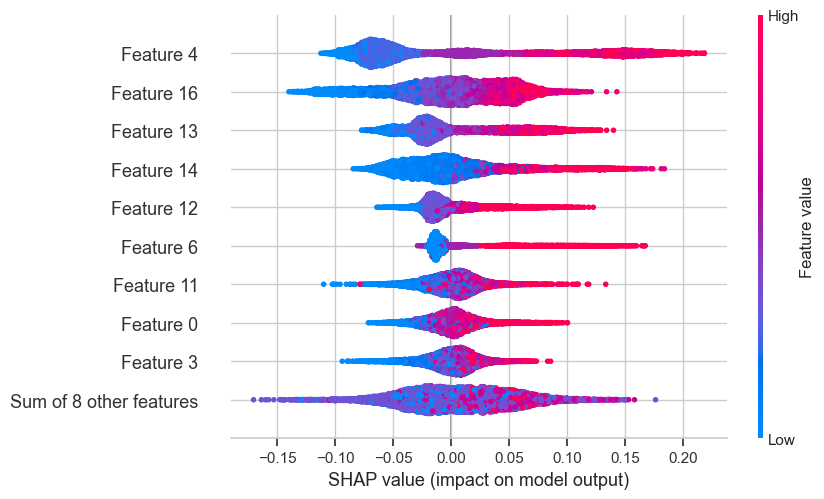

In [58]:
shap.plots.beeswarm(shap_values_rf[:, :, 1])

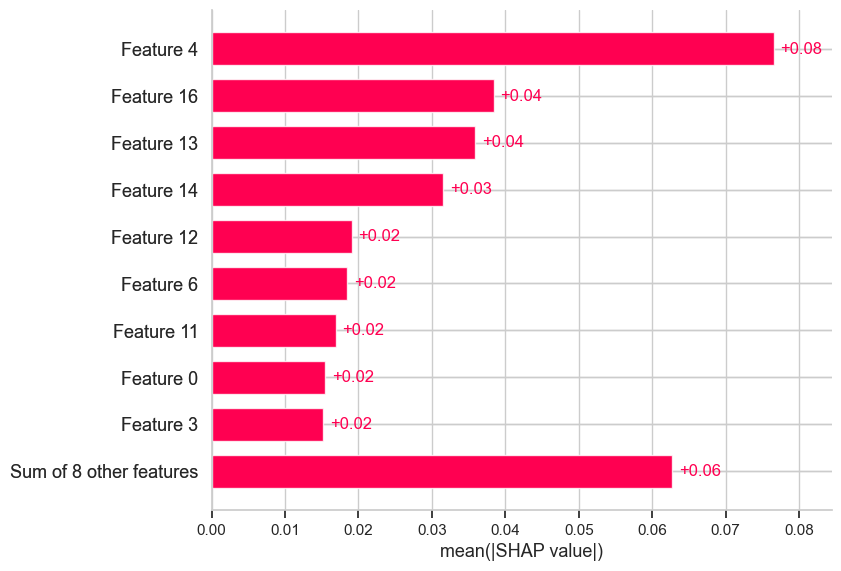

In [60]:
shap.plots.bar(shap_values_rf[:, :, 1])

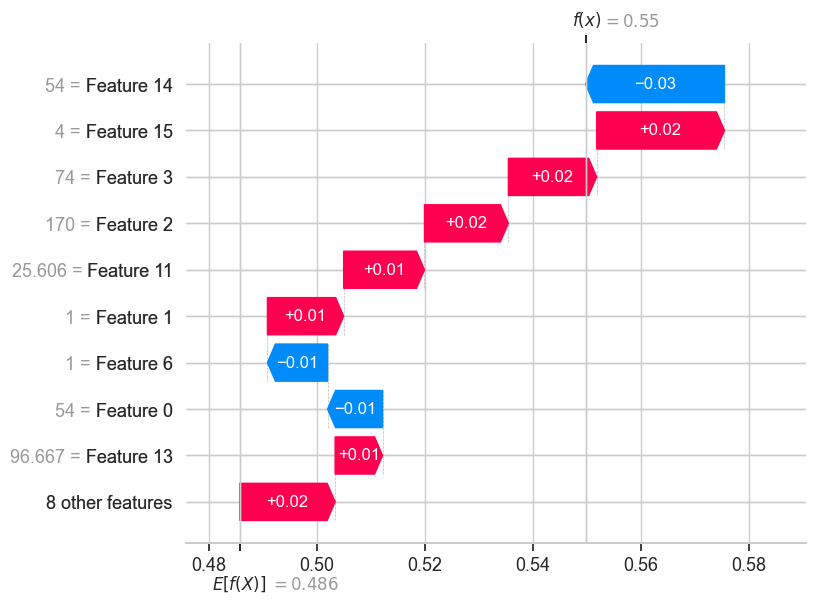

In [61]:
sample_index = 0   
shap.plots.waterfall(shap_values_rf[sample_index, :, 1])

C:\Users\Sigma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


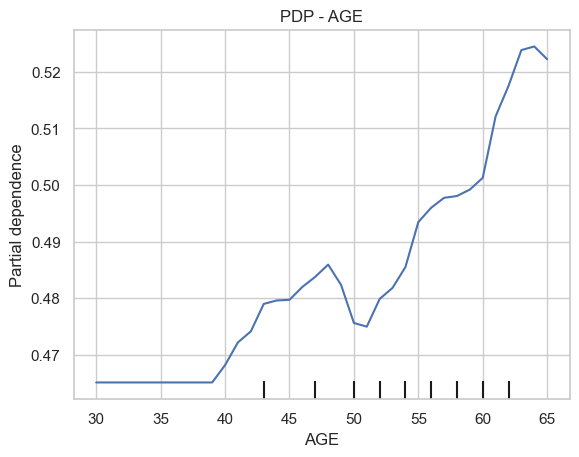

C:\Users\Sigma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 4 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


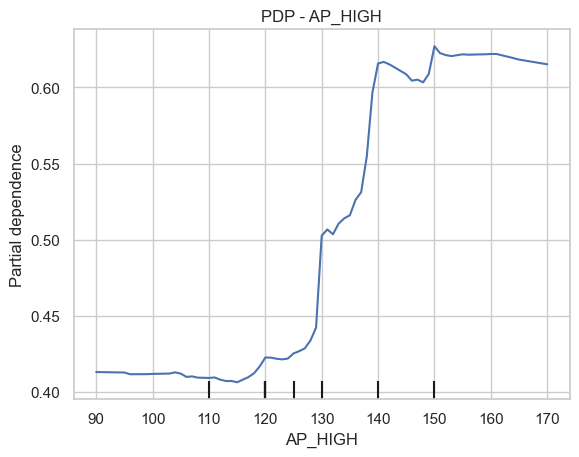

C:\Users\Sigma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 6 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


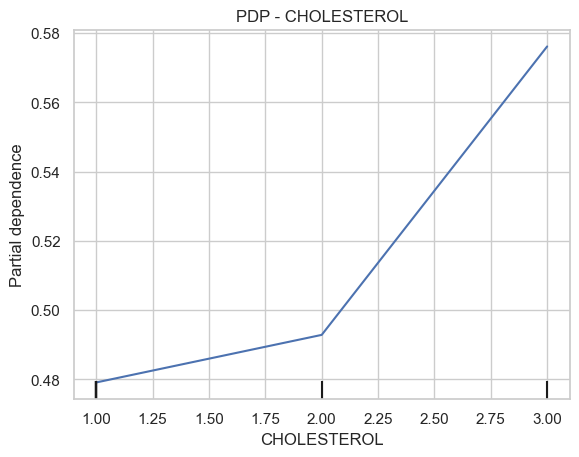

In [62]:
from sklearn.inspection import PartialDependenceDisplay

top_features = ['AGE', 'AP_HIGH', 'CHOLESTEROL']  

for feat in top_features:
    PartialDependenceDisplay.from_estimator(
        rf_comp,
        M_test,
        [feat],
        kind='average'
    )
    plt.title(f'PDP - {feat}')
    plt.show()

C:\Users\Sigma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 0 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


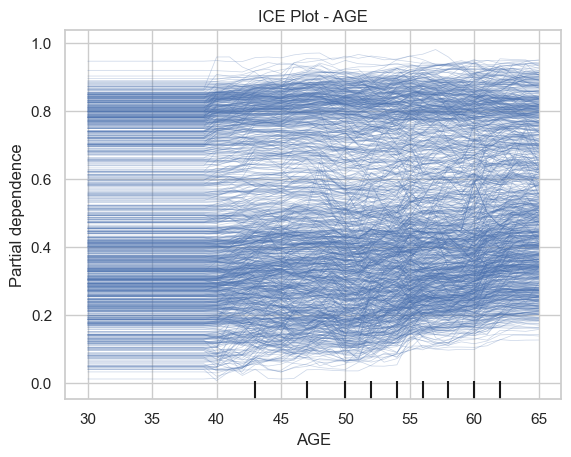

C:\Users\Sigma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 4 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


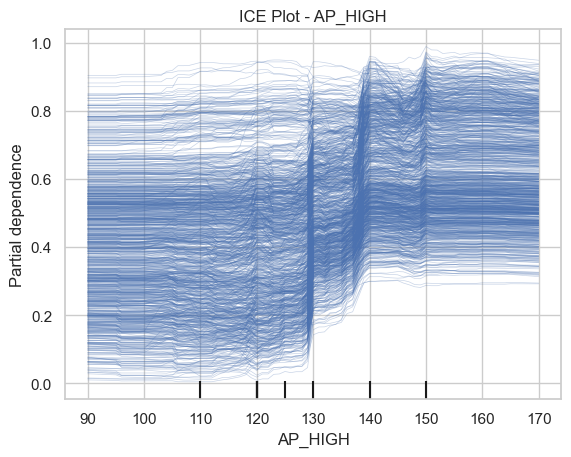

C:\Users\Sigma\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 6 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


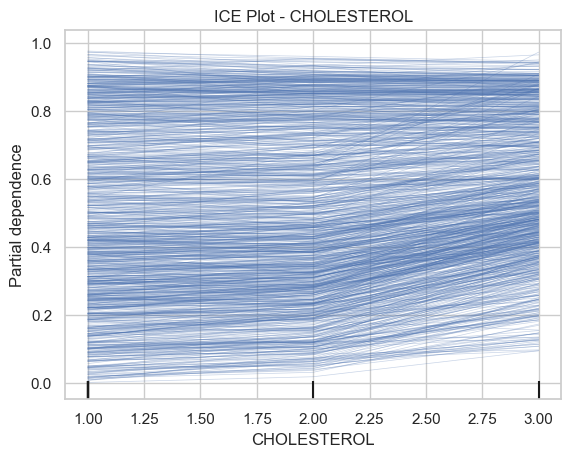

In [63]:
for feat in top_features:
    PartialDependenceDisplay.from_estimator(
        rf_comp,
        M_test,
        [feat],
        kind='individual'
    )
    plt.title(f'ICE Plot - {feat}')
    plt.show()

In [82]:
top_rf_perm = perm_rf_df.head(5)['Feature'].tolist()
top_mlp_perm = perm_mlp_df.head(5)['Feature'].tolist()
top_svm_perm = perm_svm_df.head(5)['Feature'].tolist()
top_cnn_perm = perm_cnn_df.head(5)['Feature'].tolist()

interpret_summary = pd.DataFrame({
    'Random Forest': pd.Series(top_rf_perm),
    'MLP': pd.Series(top_mlp_perm),
    'SVM': pd.Series(top_svm_perm),
    'Modified 1D CNN': pd.Series(top_cnn_perm)
})

print(interpret_summary)

       Random Forest             MLP             SVM Modified 1D CNN
0            AP_HIGH     CHOLESTEROL  PULSE_PRESSURE             AGE
1         RISK_SCORE     AGE_BP_RISK     AGE_BP_RISK         AP_HIGH
2        AGE_BP_RISK             AGE     CHOLESTEROL     AGE_BP_RISK
3                MAP  PULSE_PRESSURE         AP_HIGH             MAP
4  PHYSICAL_ACTIVITY             MAP      RISK_SCORE      RISK_SCORE
